# Sistema de Recomendação — Duas Visões
## Stack Overflow Developer Survey

Este notebook implementa um sistema de recomendação **Content-Based Filtering** com duas perspetivas:

| Visão | Quem usa | Pergunta respondida |
|---|---|---|
| 👨‍💻 **Programador** | Desenvolvedor | *"Que tecnologias devo aprender a seguir?"* |
| 🏢 **Recrutador** | Empresa/RH | *"Que programadores têm o perfil que procuro?"* |

### Abordagem
- **Itens** = tecnologias (linguagens, frameworks, ferramentas, bases de dados)
- **Utilizadores** = respondentes do survey
- **Perfil** = vetor binário das tecnologias usadas (`HaveWorkedWith`)
- **Similaridade** = Cosine Similarity

## 1. Importações e Configuração

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity

np.random.seed(42)
pd.set_option('display.max_colwidth', 60)
print('Bibliotecas carregadas com sucesso.')

Bibliotecas carregadas com sucesso.


## 2. Carregar o Dataset

In [17]:
df = pd.read_csv("../DATASET/dataset_expandido.csv", low_memory=False)
print(f'Shape: {df.shape}')
df[['DevType', 'YearsCodePro', 'Country', 'EdLevel', 'LanguageHaveWorkedWith']].head(3)

Shape: (165437, 117)


,DevType,YearsCodePro,Country,EdLevel,LanguageHaveWorkedWith
0,Sem dado,Sem dado,United States of America,Primary/elementary school,Sem dado
1,"Developer, full-stack",17,United Kingdom of Great Britain and Northern Ireland,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Bash/Shell (all shells);Go;HTML/CSS;Java;JavaScript;Pyth...
2,Developer Experience,27,United Kingdom of Great Britain and Northern Ireland,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",C#


## 3. Construir a Matriz Utilizador-Tecnologia

In [18]:
have_worked_cols = [
    'LanguageHaveWorkedWith',
    'DatabaseHaveWorkedWith',
    'PlatformHaveWorkedWith',
    'WebframeHaveWorkedWith',
    'MiscTechHaveWorkedWith',
    'ToolsTechHaveWorkedWith',
]

want_cols = [
    'LanguageWantToWorkWith',
    'DatabaseWantToWorkWith',
    'PlatformWantToWorkWith',
    'WebframeWantToWorkWith',
    'MiscTechWantToWorkWith',
    'ToolsTechWantToWorkWith',
]

def build_binary_matrix(df, cols):
    """Constrói matriz binária utilizador x tecnologia."""
    all_techs = set()
    for col in cols:
        for val in df[col].dropna():
            if val != 'Sem dado':
                all_techs.update([t.strip() for t in str(val).split(';')])
    all_techs = sorted(all_techs)

    matrix = pd.DataFrame(0, index=df.index, columns=all_techs)
    for col in cols:
        for idx, val in df[col].items():
            if pd.notna(val) and val != 'Sem dado':
                for tech in [t.strip() for t in str(val).split(';')]:
                    if tech in matrix.columns:
                        matrix.at[idx, tech] = 1
    return matrix

print('A construir matrizes...')
user_tech_matrix = build_binary_matrix(df, have_worked_cols)
user_want_matrix = build_binary_matrix(df, want_cols)

# Filtrar utilizadores com pelo menos 1 tecnologia
valid_mask = user_tech_matrix.sum(axis=1) > 0
user_tech_matrix = user_tech_matrix[valid_mask]
df_valid = df.loc[user_tech_matrix.index].copy()

print(f'Utilizadores válidos: {len(user_tech_matrix)}')
print(f'Tecnologias únicas: {user_tech_matrix.shape[1]}')

A construir matrizes...
Utilizadores válidos: 151751
Tecnologias únicas: 219


In [4]:
# Similaridade entre tecnologias (para a visão do programador)
# Matriz tecnologia x tecnologia — viável porque há ~300 tecnologias
print('A calcular similaridade entre tecnologias...')
tech_similarity_df = pd.DataFrame(
    cosine_similarity(user_tech_matrix.T),
    index=user_tech_matrix.columns,
    columns=user_tech_matrix.columns
)

# NOTA: NÃO calculamos user_similarity_df aqui.
# Com 150k+ utilizadores, a matriz user x user ocuparia ~172 GiB de RAM.
# A visão do recrutador calcula a similaridade on-demand (vaga vs todos os utilizadores),
# o que apenas requer um vetor de 150k valores — sem problema de memória.

print('Matriz de similaridade calculada.')
print(f'Shape: tecnologia x tecnologia = {tech_similarity_df.shape}')

A calcular similaridade entre tecnologias...
Matriz de similaridade calculada.
Shape: tecnologia x tecnologia = (219, 219)


---
# 👨‍💻 VISÃO 1: PROGRAMADOR
## *"Que tecnologias devo aprender a seguir?"*

O programador fornece as tecnologias que já usa e recebe recomendações de tecnologias complementares, com base no que programadores com perfil semelhante também usam.

### 4a. Recomendação por Perfil de Tecnologias (Programador existente no dataset)

In [5]:
def recommend_for_developer(user_idx, user_tech_matrix, tech_similarity_df,
                             df_meta, top_n=10, verbose=True):
    """
    VISÃO PROGRAMADOR:
    Dado um utilizador do dataset, recomenda tecnologias que ainda não usa
    com base na similaridade com as que já usa.
    """
    user_row = user_tech_matrix.loc[user_idx]
    used_techs = user_row[user_row == 1].index.tolist()
    not_used_techs = user_row[user_row == 0].index.tolist()

    if verbose:
        meta = df_meta.loc[user_idx]
        print('=' * 55)
        print(f'👨‍💻 PERFIL DO PROGRAMADOR')
        print('=' * 55)
        print(f'  DevType       : {meta["DevType"]}')
        print(f'  Anos de código: {meta["YearsCodePro"]}')
        print(f'  País          : {meta["Country"]}')
        print(f'  Educação      : {meta["EdLevel"]}')
        print(f'  Tecnologias   : {len(used_techs)}')
        print(f'  Exemplos      : {', '.join(used_techs[:8])}{'...' if len(used_techs) > 8 else ''}')
        print()

    # Score: similaridade média com tecnologias já usadas
    scores = {}
    for tech in not_used_techs:
        if tech in tech_similarity_df.index:
            scores[tech] = tech_similarity_df.loc[tech, used_techs].mean()

    results = pd.Series(scores).sort_values(ascending=False).head(top_n)
    recs = results.reset_index()
    recs.columns = ['Tecnologia Recomendada', 'Score']
    return recs

# Exemplo: programador no índice 1
valid_users = user_tech_matrix.index.tolist()
recs_dev = recommend_for_developer(valid_users[1], user_tech_matrix, tech_similarity_df, df_valid)
print('\n🎯 RECOMENDAÇÕES DE TECNOLOGIAS:')
print(recs_dev.to_string(index=False))

👨‍💻 PERFIL DO PROGRAMADOR
  DevType       : Developer Experience
  Anos de código: 27
  País          : United Kingdom of Great Britain and Northern Ireland
  Educação      : Master’s degree (M.A., M.S., M.Eng., MBA, etc.)
  Tecnologias   : 8
  Exemplos      : .NET (5+), .NET Framework (1.0 - 4.8), .NET MAUI, ASP.NET CORE, C#, Firebase Realtime Database, Google Cloud, MSBuild


🎯 RECOMENDAÇÕES DE TECNOLOGIAS:
Tecnologia Recomendada    Score
                 NuGet 0.461273
               ASP.NET 0.416677
  Microsoft SQL Server 0.411402
Visual Studio Solution 0.378739
       Microsoft Azure 0.341052
                   SQL 0.328307
            JavaScript 0.315321
              HTML/CSS 0.302596
                Blazor 0.284090
            PowerShell 0.282400


### 4b. Recomendação para Novo Programador (não está no dataset)

In [6]:
def recommend_for_new_developer(my_techs, user_tech_matrix, tech_similarity_df, top_n=10):
    """
    VISÃO PROGRAMADOR — Cold Start:
    O programador indica as tecnologias que já usa (lista manual)
    e recebe recomendações sem precisar de estar no dataset.
    """
    # Verificar quais existem no sistema
    valid_techs = [t for t in my_techs if t in tech_similarity_df.index]
    not_found = [t for t in my_techs if t not in tech_similarity_df.index]

    print('=' * 55)
    print('👨‍💻 NOVO PROGRAMADOR')
    print('=' * 55)
    print(f'  Tecnologias reconhecidas : {valid_techs}')
    if not_found:
        print(f'  Não encontradas no sistema: {not_found}')
    print()

    if not valid_techs:
        print('Nenhuma tecnologia reconhecida.')
        return None

    all_techs = tech_similarity_df.index.tolist()
    not_used = [t for t in all_techs if t not in valid_techs]

    scores = {}
    for tech in not_used:
        scores[tech] = tech_similarity_df.loc[tech, valid_techs].mean()

    results = pd.Series(scores).sort_values(ascending=False).head(top_n)
    recs = results.reset_index()
    recs.columns = ['Tecnologia Recomendada', 'Score']
    return recs

# Exemplo: programador Python/Django/PostgreSQL
meu_perfil = ['Python', 'Django', 'PostgreSQL', 'Git', 'Docker']
recs_novo = recommend_for_new_developer(meu_perfil, user_tech_matrix, tech_similarity_df)
print('🎯 RECOMENDAÇÕES:')
print(recs_novo.to_string(index=False))

👨‍💻 NOVO PROGRAMADOR
  Tecnologias reconhecidas : ['Python', 'Django', 'PostgreSQL', 'Docker']
  Não encontradas no sistema: ['Git']

🎯 RECOMENDAÇÕES:
   Tecnologia Recomendada    Score
               JavaScript 0.509504
                      SQL 0.497031
                      Pip 0.493853
Amazon Web Services (AWS) 0.467212
                      npm 0.466839
                 HTML/CSS 0.465252
  Bash/Shell (all shells) 0.439362
               TypeScript 0.426659
                   SQLite 0.422327
                    MySQL 0.414895


C:\Users\Utilizador\AppData\Local\Temp\ipykernel_24484\4190944245.py:20: UserWarning: Glyph 128104 (\N{MAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Utilizador\AppData\Local\Temp\ipykernel_24484\4190944245.py:20: UserWarning: Glyph 128187 (\N{PERSONAL COMPUTER}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Utilizador\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128104 (\N{MAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Utilizador\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128187 (\N{PERSONAL COMPUTER}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


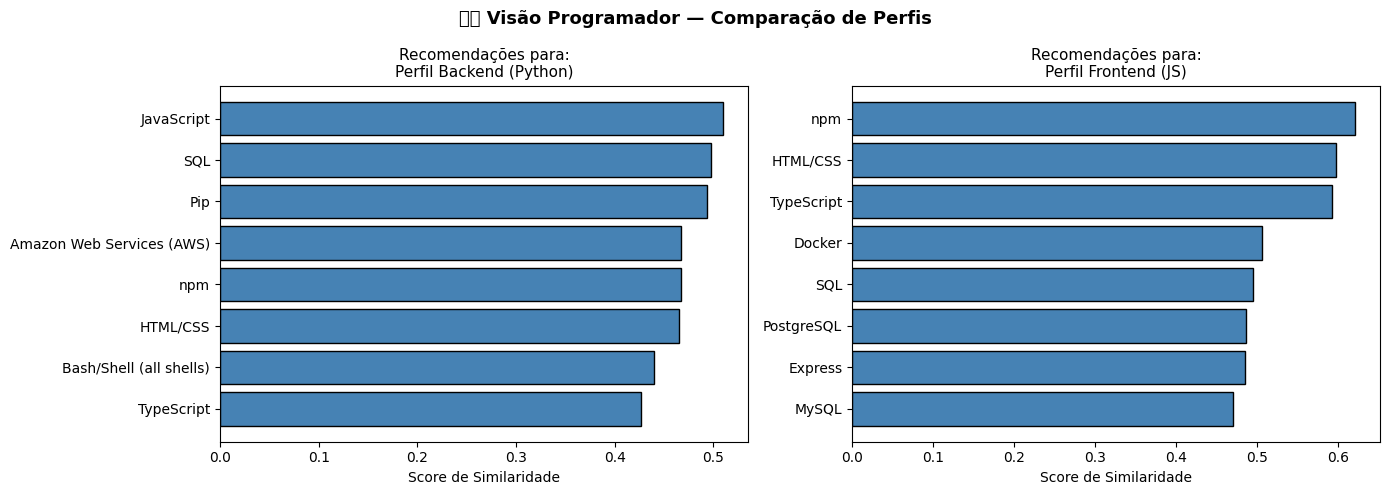

In [7]:
# Comparação: dois perfis diferentes
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

perfil_a = ['Python', 'Django', 'PostgreSQL', 'Docker']
perfil_b = ['JavaScript', 'React', 'Node.js', 'MongoDB']

for ax, perfil, titulo in zip(axes, [perfil_a, perfil_b],
                               ['Perfil Backend (Python)', 'Perfil Frontend (JS)']):
    valid = [t for t in perfil if t in tech_similarity_df.index]
    not_used = [t for t in tech_similarity_df.index if t not in valid]
    scores = {t: tech_similarity_df.loc[t, valid].mean() for t in not_used
              if t in tech_similarity_df.index}
    top = pd.Series(scores).sort_values(ascending=False).head(8)

    ax.barh(top.index[::-1], top.values[::-1], color='steelblue', edgecolor='black')
    ax.set_title(f'Recomendações para:\n{titulo}', fontsize=11)
    ax.set_xlabel('Score de Similaridade')

plt.suptitle('👨‍💻 Visão Programador — Comparação de Perfis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
# 🏢 VISÃO 2: RECRUTADOR
## *"Que programadores têm o perfil que procuro?"*

O recrutador define as tecnologias que a vaga exige e o sistema encontra os respondentes com perfil mais próximo.

### 5a. Encontrar Candidatos para uma Vaga

In [8]:
def find_candidates(required_techs, user_tech_matrix, df_meta, top_n=10):
    """
    VISÃO RECRUTADOR:
    Dado um conjunto de tecnologias exigidas pela vaga,
    encontra os programadores com maior compatibilidade.
    """
    # Verificar tecnologias válidas
    valid_techs = [t for t in required_techs if t in user_tech_matrix.columns]
    not_found = [t for t in required_techs if t not in user_tech_matrix.columns]

    print('=' * 55)
    print('🏢 PERFIL DA VAGA')
    print('=' * 55)
    print(f'  Tecnologias exigidas     : {valid_techs}')
    if not_found:
        print(f'  Não encontradas no sistema: {not_found}')
    print()

    if not valid_techs:
        return None

    # Vetor da vaga (binário: 1 se exige a tecnologia)
    job_vector = np.zeros(user_tech_matrix.shape[1])
    for tech in valid_techs:
        job_vector[user_tech_matrix.columns.get_loc(tech)] = 1

    # Similaridade entre a vaga e cada utilizador
    similarities = cosine_similarity(
        job_vector.reshape(1, -1),
        user_tech_matrix.values
    ).flatten()

    top_indices = np.argsort(similarities)[::-1][:top_n]
    top_users = user_tech_matrix.index[top_indices]
    top_scores = similarities[top_indices]

    # Montar resultado com metadados
    results = df_meta.loc[top_users, ['DevType', 'YearsCodePro', 'Country',
                                       'EdLevel', 'RemoteWork']].copy()
    results['Compatibilidade'] = top_scores

    # % de tecnologias exigidas que o candidato tem
    coverage = []
    for u in top_users:
        user_techs = set(user_tech_matrix.loc[u][user_tech_matrix.loc[u] == 1].index)
        hits = len(set(valid_techs) & user_techs)
        coverage.append(f'{hits}/{len(valid_techs)}')
    results['Tecnologias Match'] = coverage

    return results.sort_values('Compatibilidade', ascending=False)

# Exemplo 1: Vaga de Data Scientist
vaga_data_science = ['Python', 'TensorFlow', 'PostgreSQL', 'Docker', 'Jupyter Notebook']
candidatos = find_candidates(vaga_data_science, user_tech_matrix, df_valid)
print('🎯 TOP CANDIDATOS:')
candidatos.head(10)

🏢 PERFIL DA VAGA
  Tecnologias exigidas     : ['Python', 'TensorFlow', 'PostgreSQL', 'Docker']
  Não encontradas no sistema: ['Jupyter Notebook']

🎯 TOP CANDIDATOS:


,DevType,YearsCodePro,Country,EdLevel,RemoteWork,Compatibilidade,Tecnologias Match
29857,"Developer, back-end",10,Germany,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Remote,0.750000,3/4
152188,"Developer, back-end",18,Ukraine,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Remote,0.750000,3/4
49307,Data scientist or machine learning specialist,7,United States of America,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)","Hybrid (some remote, some in-person)",0.750000,3/4
138513,Data scientist or machine learning specialist,7,United States of America,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)","Hybrid (some remote, some in-person)",0.750000,3/4
3279,"Developer, back-end",18,Ukraine,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Remote,0.750000,3/4
147494,"Developer, back-end",18,Ukraine,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Remote,0.750000,3/4
126652,Data scientist or machine learning specialist,7,United States of America,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)","Hybrid (some remote, some in-person)",0.750000,3/4
63864,"Developer, back-end",3,Guatemala,Some college/university study without earning a degree,Remote,0.707107,2/4
122446,"Developer, QA or test",Less than 1 year,Ukraine,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)","Hybrid (some remote, some in-person)",0.707107,2/4
115149,Data or business analyst,Sem dado,United States of America,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Sem dado,0.707107,2/4


In [9]:
# Exemplo 2: Vaga de Full-Stack Developer
vaga_fullstack = ['JavaScript', 'React', 'Node.js', 'PostgreSQL', 'Docker', 'Git']
candidatos_fs = find_candidates(vaga_fullstack, user_tech_matrix, df_valid)
print('🎯 TOP CANDIDATOS — Full-Stack:')
candidatos_fs.head(10)

🏢 PERFIL DA VAGA
  Tecnologias exigidas     : ['JavaScript', 'React', 'Node.js', 'PostgreSQL', 'Docker']
  Não encontradas no sistema: ['Git']



🎯 TOP CANDIDATOS — Full-Stack:


,DevType,YearsCodePro,Country,EdLevel,RemoteWork,Compatibilidade,Tecnologias Match
134468,"Developer, back-end",1,India,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",In-person,0.894427,4/5
40542,"Developer, back-end",1,India,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",In-person,0.894427,4/5
101891,"Developer, back-end",1,India,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",In-person,0.894427,4/5
73748,"Developer, back-end",1,India,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",In-person,0.894427,4/5
62945,"Developer, full-stack",8,Ukraine,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Remote,0.845154,5/5
5362,"Developer, front-end",2,Serbia,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Sem dado,0.845154,5/5
88043,"Developer, front-end",2,Serbia,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Sem dado,0.845154,5/5
108160,"Developer, front-end",2,Serbia,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Sem dado,0.845154,5/5
138993,"Developer, full-stack",8,Ukraine,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Remote,0.845154,5/5
20481,"Developer, full-stack",Less than 1 year,United Kingdom of Great Britain and Northern Ireland,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)","Hybrid (some remote, some in-person)",0.745356,5/5


### 5b. Comparar Candidatos para uma Vaga (Visualização)

In [20]:
import plotly.graph_objects as go

def plot_candidate_comparison(required_techs, user_tech_matrix, df_meta, top_n=8):
    valid_techs = [t for t in required_techs if t in user_tech_matrix.columns]

    job_vector = np.zeros(user_tech_matrix.shape[1])
    for tech in valid_techs:
        job_vector[user_tech_matrix.columns.get_loc(tech)] = 1

    similarities = cosine_similarity(
        job_vector.reshape(1, -1), user_tech_matrix.values
    ).flatten()

    top_indices = np.argsort(similarities)[::-1][:top_n]
    top_users = user_tech_matrix.index[top_indices]

    heatmap_data = user_tech_matrix.loc[top_users, valid_techs]
    labels = [f'C{i+1} | {df_meta.loc[u, "DevType"][:25]}'
               for i, u in enumerate(top_users)]
    heatmap_data.index = labels

    fig = go.Figure(data=go.Heatmap(
        z=heatmap_data.values,
        x=list(valid_techs),
        y=list(labels),
        colorscale=[[0, 'red'], [1, 'green']],
        zmin=0, zmax=1,
        text=heatmap_data.values,
        texttemplate="%{text}",
        showscale=False
    ))

    fig.update_layout(
        title='🏢 Compatibilidade Candidatos × Tecnologias Exigidas',
        xaxis_title='Tecnologias da Vaga',
        yaxis_title='Candidatos',
        xaxis=dict(tickangle=-30),
        plot_bgcolor='rgba(0,0,0,0)',
        paper_bgcolor='rgba(0,0,0,0)',
        font=dict(color='white')
    )

    fig.write_html('../Public/assets/heatmap_recrutador.html')
    fig.show()

plot_candidate_comparison(vaga_data_science, user_tech_matrix, df_valid)

C:\Users\Utilizador\AppData\Local\Temp\ipykernel_24484\3754462938.py:34: UserWarning: Glyph 127970 (\N{OFFICE BUILDING}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Utilizador\AppData\Local\Temp\ipykernel_24484\3754462938.py:35: UserWarning: Glyph 127970 (\N{OFFICE BUILDING}) missing from font(s) DejaVu Sans.
  plt.savefig("matriz_compatibilidade.png", dpi=150, bbox_inches="tight")
C:\Users\Utilizador\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127970 (\N{OFFICE BUILDING}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


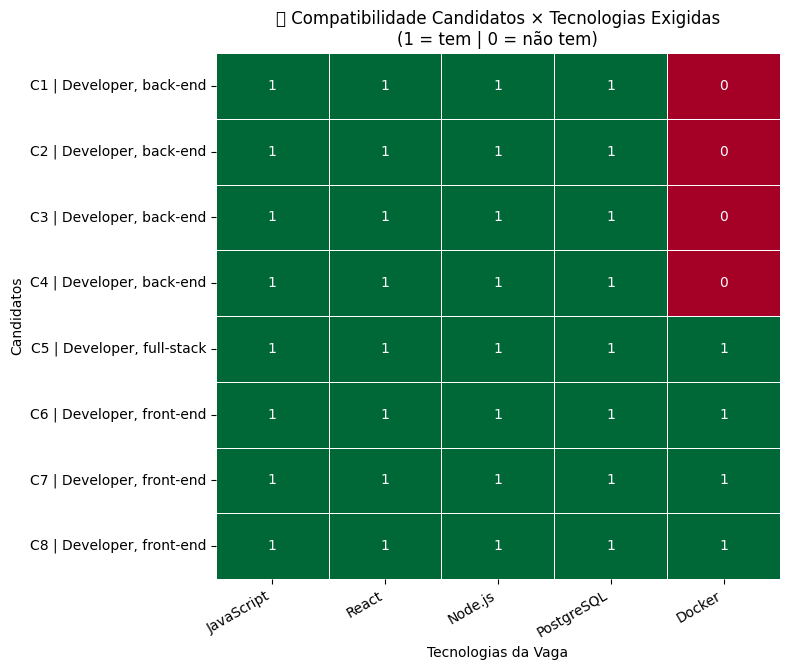

In [11]:
# Visualização para a vaga de Full-Stack
plot_candidate_comparison(vaga_fullstack, user_tech_matrix, df_valid)

### 5c. Análise de Compatibilidade por DevType

--- Vaga Data Scientist ---


C:\Users\Utilizador\AppData\Local\Temp\ipykernel_24484\1647381317.py:31: UserWarning: Glyph 127970 (\N{OFFICE BUILDING}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Utilizador\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127970 (\N{OFFICE BUILDING}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


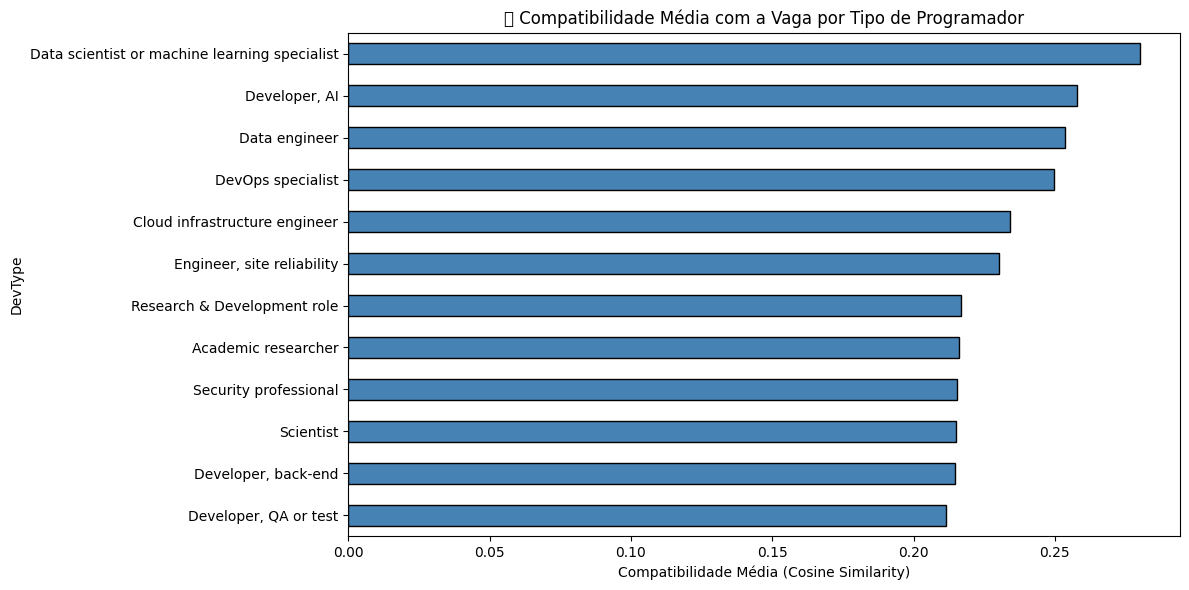

,DevType,Compatibilidade
0,Data scientist or machine learning specialist,0.280232
1,"Developer, AI",0.257856
2,Data engineer,0.253418
3,DevOps specialist,0.249572
4,Cloud infrastructure engineer,0.234050
5,"Engineer, site reliability",0.230209
6,Research & Development role,0.216735
7,Academic researcher,0.216082
8,Security professional,0.215515
9,Scientist,0.214914


In [12]:
def analyze_by_devtype(required_techs, user_tech_matrix, df_meta):
    """
    Mostra a compatibilidade média por tipo de programador.
    Útil para o recrutador perceber de que perfis vêm os melhores candidatos.
    """
    valid_techs = [t for t in required_techs if t in user_tech_matrix.columns]

    job_vector = np.zeros(user_tech_matrix.shape[1])
    for tech in valid_techs:
        job_vector[user_tech_matrix.columns.get_loc(tech)] = 1

    similarities = cosine_similarity(
        job_vector.reshape(1, -1), user_tech_matrix.values
    ).flatten()

    result = df_meta[['DevType']].copy()
    result['Compatibilidade'] = similarities
    result = result[result['DevType'] != 'Sem dado']

    # Explodir DevType (pode ter vários separados por ';')
    result = result.assign(DevType=result['DevType'].str.split(';')).explode('DevType')
    result['DevType'] = result['DevType'].str.strip()

    avg_compat = result.groupby('DevType')['Compatibilidade'].mean().sort_values(ascending=False)

    plt.figure(figsize=(12, 6))
    avg_compat.head(12).plot(kind='barh', color='steelblue', edgecolor='black')
    plt.title('🏢 Compatibilidade Média com a Vaga por Tipo de Programador', fontsize=12)
    plt.xlabel('Compatibilidade Média (Cosine Similarity)')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

    return avg_compat.head(10).reset_index()

print('--- Vaga Data Scientist ---')
analyze_by_devtype(vaga_data_science, user_tech_matrix, df_valid)

---
## 6. Avaliação — Precision@K (Visão Programador)

Usamos `WantToWorkWith` como ground truth:
- O sistema recomenda tecnologias com base no `HaveWorkedWith`
- Uma recomendação é **relevante** se o utilizador a indicou em `WantToWorkWith`

In [13]:
common_users = user_tech_matrix.index.intersection(user_want_matrix.index)
common_techs = user_tech_matrix.columns.intersection(user_want_matrix.columns)
user_want_eval = user_want_matrix.loc[common_users, common_techs]

def precision_at_k(user_idx, k=10):
    user_row = user_tech_matrix.loc[user_idx]
    used = set(user_row[user_row == 1].index)
    not_used = [t for t in tech_similarity_df.index if t not in used]

    scores = {t: tech_similarity_df.loc[t, list(used)].mean() for t in not_used
              if t in tech_similarity_df.index}
    top_k = sorted(scores, key=scores.get, reverse=True)[:k]

    if user_idx not in user_want_eval.index:
        return None
    wants = set(user_want_eval.loc[user_idx][user_want_eval.loc[user_idx] == 1].index) - used
    if not wants:
        return None

    return sum(1 for t in top_k if t in wants) / k

print('A calcular Precision@K (500 utilizadores)...')
sample = common_users[:500]
results_k = {k: [] for k in [5, 10, 15]}

for u in sample:
    for k in results_k:
        p = precision_at_k(u, k=k)
        if p is not None:
            results_k[k].append(p)

print()
print('=' * 40)
print('AVALIAÇÃO — Visão Programador')
print('=' * 40)
for k, vals in results_k.items():
    print(f'  Precision@{k:2d}: {np.mean(vals):.4f}  ({np.mean(vals)*100:.1f}%)')
print('=' * 40)

A calcular Precision@K (500 utilizadores)...

AVALIAÇÃO — Visão Programador
  Precision@ 5: 0.1157  (11.6%)
  Precision@10: 0.0994  (9.9%)
  Precision@15: 0.0955  (9.6%)


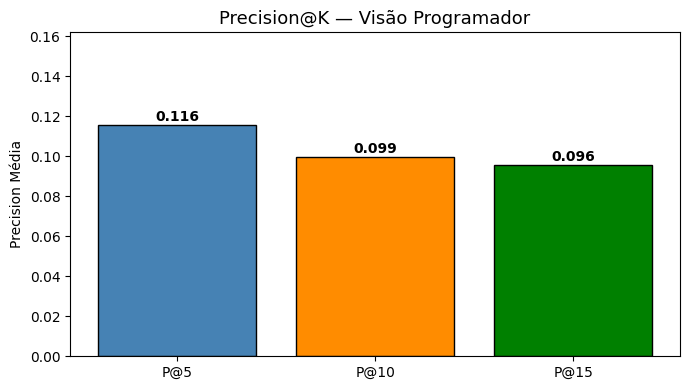

In [14]:
# Gráfico Precision@K
ks = list(results_k.keys())
means = [np.mean(results_k[k]) for k in ks]

plt.figure(figsize=(7, 4))
plt.bar([f'P@{k}' for k in ks], means, color=['steelblue', 'darkorange', 'green'], edgecolor='black')
plt.title('Precision@K — Visão Programador', fontsize=13)
plt.ylabel('Precision Média')
plt.ylim(0, max(means) * 1.4)
for i, v in enumerate(means):
    plt.text(i, v + 0.002, f'{v:.3f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

---
## 7. Análise Crítica das Duas Visões

| Aspeto | 👨‍💻 Programador | 🏢 Recrutador |
|---|---|---|
| **Input** | Tecnologias que já usa | Tecnologias que a vaga exige |
| **Output** | Tecnologias para aprender | Programadores compatíveis |
| **Similaridade** | Tecnologia ↔ Tecnologia | Vaga ↔ Utilizador |
| **Avaliação** | Precision@K (WantToWork) | Cobertura de requisitos |
| **Limitação** | Filter bubble | Não considera experiência ou soft skills |

### Limitações gerais
- O dataset não tem ratings explícitos — a presença de uma tecnologia não mede proficiência
- Um programador que usa 30 tecnologias tem vantagem injusta sobre quem usa 5
- A visão do recrutador não filtra por disponibilidade, salário, localização ou experiência real

In [15]:
print('=' * 55)
print('RESUMO FINAL')
print('=' * 55)
print(f'Tipo: Content-Based Filtering')
print(f'Métrica: Cosine Similarity')
print(f'Utilizadores: {user_tech_matrix.shape[0]}')
print(f'Tecnologias : {user_tech_matrix.shape[1]}')
print()
print('Visão Programador:')
for k, vals in results_k.items():
    print(f'  Precision@{k}: {np.mean(vals):.4f}')
print()
print('Visão Recrutador:')
print('  Compatibilidade por Cosine Similarity (vaga vs perfil)')
print('=' * 55)

RESUMO FINAL
Tipo: Content-Based Filtering
Métrica: Cosine Similarity
Utilizadores: 151751
Tecnologias : 219

Visão Programador:
  Precision@5: 0.1157
  Precision@10: 0.0994
  Precision@15: 0.0955

Visão Recrutador:
  Compatibilidade por Cosine Similarity (vaga vs perfil)
